---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 02. Exploração Visual de Dados de Imagem


Neste notebook, vamos explorar visualmente um dataset de imagens usado em tarefas de classificação com aprendizagem automática. Através da inspeção visual direta, estatísticas básicas e visualizações agregadas, procuramos entender a estrutura dos dados, a distribuição das classes, a variedade visual e eventuais problemas como desbalanceamento ou classes ambíguas.

Esta etapa é fundamental antes de qualquer treino de modelos, pois permite detetar padrões, erros ou tendências nos dados que podem afetar a aprendizagem.


## 1. Carregamento do dataset

Nesta célula é carregado o conjunto de dados **Oxford Flowers102**, um conjunto clássico de imagens de flores utilizado para tarefas de classificação visual.  

1. **Definição das transformações:**  
   O objeto `transform` define as operações de pré-processamento aplicadas a cada imagem:
   - `transforms.Resize((160, 160))` redimensiona todas as imagens para 160×160 píxeis, garantindo que têm tamanho uniforme.  
   - `transforms.ToTensor()` converte cada imagem para um tensor PyTorch, com valores normalizados entre 0 e 1.  

   Estas transformações asseguram que todas as imagens têm dimensões compatíveis com os modelos que serão usados mais à frente e que os valores de píxel estão num intervalo adequado para operações numéricas estáveis.

2. **Carregamento do dataset:**  
   O `datasets.Flowers102` é um dataset incluído na biblioteca `torchvision`, contendo 102 categorias de flores.  
   O parâmetro `split='train'` indica que serão carregadas as imagens da parte de treino, e `download=True` garante que o conjunto é automaticamente transferido e armazenado na pasta `data/` se ainda não existir localmente.  
   O argumento `transform=transform` assegura que todas as imagens são processadas de acordo com as transformações definidas acima.

**Nota pedagógica:**  
Esta célula cria um conjunto de treino pronto a ser explorado e visualizado.  
Embora aqui não se defina a divisão entre treino, validação e teste, o `split='train'` carrega o subconjunto de treino pré-definido no dataset original.  

Em contextos aplicados, pode-se facilmente substituir o *Flowers102* por um **dataset próprio**.  
Para isso, basta organizar as imagens em pastas onde cada subpasta representa uma classe (por exemplo, `data/minhas_imagens/classe1/`, `classe2/`, etc.) e usar a classe `datasets.ImageFolder`:

```python
from torchvision.datasets import ImageFolder
dataset = ImageFolder(root='data/minhas_imagens', transform=transform)

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

dataset = datasets.Flowers102(root='data', split='train', download=True, transform=transform)


## 2. Visualização de imagens aleatórias

Esta célula apresenta um conjunto de imagens aleatórias do dataset carregado anteriormente, permitindo inspecionar visualmente o tipo e a diversidade das amostras.

1. **Seleção aleatória de imagens:**  
   - `random.sample(range(len(dataset)), 16)` escolhe 16 índices aleatórios dentro do dataset.  
   - Para cada índice selecionado, é extraída apenas a imagem (`dataset[i][0]`), ignorando o rótulo.

2. **Criação de uma grelha de imagens:**  
   - A função `torchvision.utils.make_grid(images, nrow=4, normalize=True)` organiza as 16 imagens numa grelha de 4×4, ajustando automaticamente os valores de píxel para o intervalo `[0, 1]`.  
   - O argumento `normalize=True` é útil porque os tensores PyTorch podem conter valores fora desse intervalo após transformações.

3. **Visualização:**  
   - O tensor da grelha é convertido para o formato `(altura, largura, canais)` com `permute(1, 2, 0)` — o formato que o Matplotlib espera.  
   - As imagens são mostradas com `plt.imshow(...)`, sem eixos, para destacar o conteúdo visual.

**Nota pedagógica:**  
Esta célula é particularmente útil para **verificar se o carregamento e as transformações do dataset estão corretos** — por exemplo, se as imagens não estão distorcidas, invertidas ou com cores incorretas.  
Quando se usa um dataset próprio com `ImageFolder`, este passo é essencial para confirmar que as imagens estão a ser lidas a partir das pastas corretas e que o pré-processamento (como `Resize` ou `Normalize`) mantém as proporções adequadas.

Se o dataset tiver classes muito desiguais (por exemplo, mais imagens de uma classe do que de outra), uma inspeção visual inicial pode também revelar esse desbalanceamento, ajudando a planear estratégias de *data augmentation* ou reamostragem antes do treino.

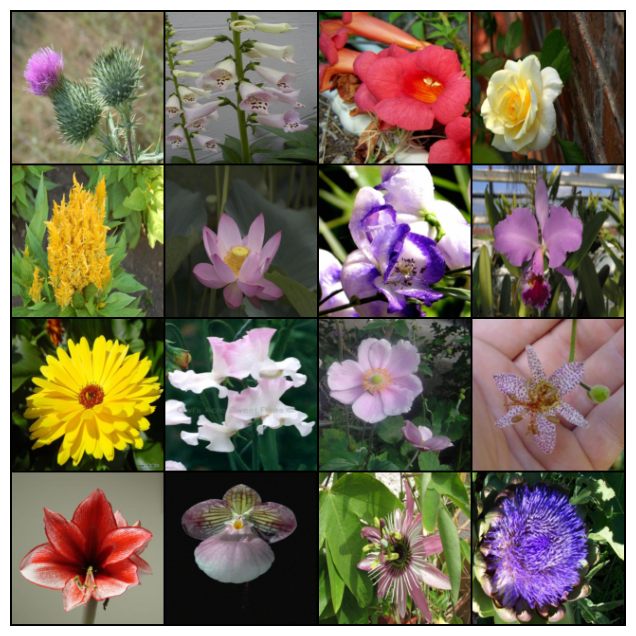

In [2]:
indices = random.sample(range(len(dataset)), 16)
images = [dataset[i][0] for i in indices]

grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

## 3. Distribuição das classes

Esta célula examina a **distribuição das classes** no conjunto de treino, ajudando a perceber se o dataset está equilibrado ou se existem categorias com muito mais imagens do que outras.

1. **Extração dos rótulos:**  
   - O atributo `dataset._labels` contém o identificador da classe de cada imagem (inteiro entre 0 e 101 no caso do *Flowers102*).  
   - É convertido para um tensor PyTorch (`torch.tensor(...)`) e depois para um *DataFrame* pandas, o que facilita a visualização com o Seaborn.

2. **Criação do gráfico:**  
   - A função `sns.countplot(...)` gera um gráfico de barras com a contagem de imagens por classe.  
   - O eixo *x* mostra os identificadores das classes e o eixo *y* mostra o número de amostras em cada uma.  
   - O estilo `palette='viridis'` e o `plt.tight_layout()` garantem uma visualização legível e compacta.

3. **Interpretação:**  
   O *Flowers102* é um conjunto **ligeiramente desbalanceado**, com algumas classes (espécies de flores) representadas por mais imagens do que outras.  
   Visualizações como esta permitem identificar esse tipo de desigualdade antes do treino, o que é importante para evitar que o modelo aprenda a privilegiar as classes mais frequentes.

**Nota pedagógica:**  
Com datasets personalizados, este tipo de análise é ainda mais relevante.  
Ao utilizar `ImageFolder`, pode-se obter o número de amostras por classe com:
```python
from collections import Counter
from torchvision.datasets import ImageFolder
dataset = ImageFolder('data/minhas_imagens', transform=transform)
print(Counter([label for _, label in dataset]))

Um dataset muito desequilibrado pode requerer:
	- técnicas de data augmentation (gerar mais exemplos de classes minoritárias),
	- amostragem ponderada (WeightedRandomSampler),
	- ou métricas de avaliação que penalizem erros em classes raras (F1-score, balanced accuracy).
Esta verificação inicial é uma boa prática antes de iniciar qualquer fase de treino ou fine-tuning.

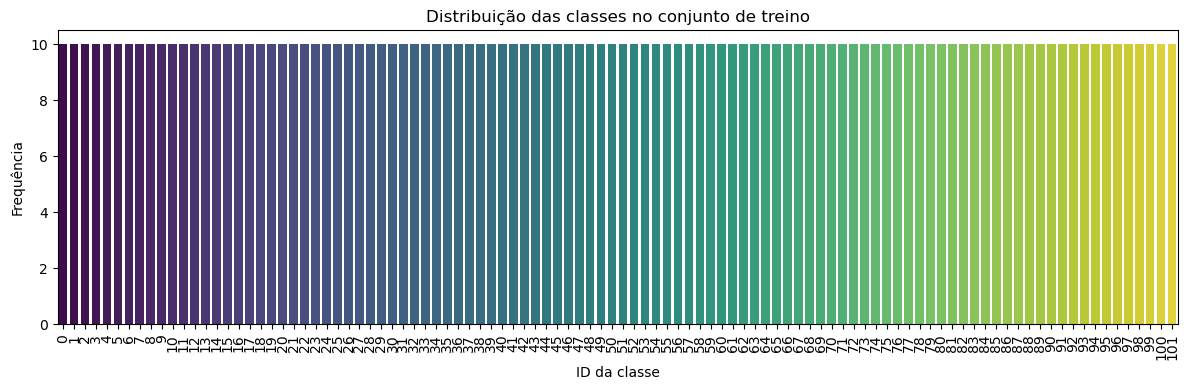

In [3]:
labels = torch.tensor(dataset._labels)
df = pd.DataFrame(labels.numpy(), columns=['classe'])

plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='classe', hue='classe', palette='viridis', legend=False)
plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("ID da classe")
plt.ylabel("Frequência")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Visualização de amostras por classe

Esta célula mostra um pequeno painel de imagens agrupadas por classe, permitindo observar diferenças visuais entre categorias do dataset.

1. **Seleção de classes representativas:**  
   - A lista `classes_escolhidas = [0, 10, 50, 90]` define quatro classes específicas do conjunto *Flowers102*.  
   - Cada número representa o identificador interno de uma classe (não necessariamente o nome da flor).

2. **Amostragem de imagens:**  
   - Para cada classe escolhida, são recolhidas as quatro primeiras imagens correspondentes.  
   - O código percorre o dataset e seleciona apenas as imagens cujo rótulo (`dataset._labels[j]`) coincide com a classe desejada.

3. **Visualização em grelha:**  
   - Cada linha da figura corresponde a uma classe, com quatro imagens lado a lado.  
   - A operação `(img * 0.5 + 0.5).clamp(0, 1)` faz a “desnormalização”, restaurando as cores originais após a conversão em tensor.  
   - As imagens são exibidas com `plt.imshow(...)`, sem eixos, e com o identificador da classe no título.

**Nota pedagógica:**  
Esta visualização permite **comparar o aspeto visual das diferentes classes** e perceber quão semelhantes ou distintas são entre si.  
É útil para refletir sobre a dificuldade da tarefa de classificação:  
- classes com flores de formatos, cores ou texturas muito parecidas tendem a ser mais difíceis de distinguir;  
- um modelo bem treinado deve conseguir encontrar padrões subtis que escapam à observação humana.  

Com datasets próprios (por exemplo, imagens industriais, médicas ou artísticas), esta abordagem é igualmente importante: inspecionar algumas amostras por classe ajuda a confirmar se a rotulagem foi feita corretamente e se as imagens representam de facto as categorias pretendidas.

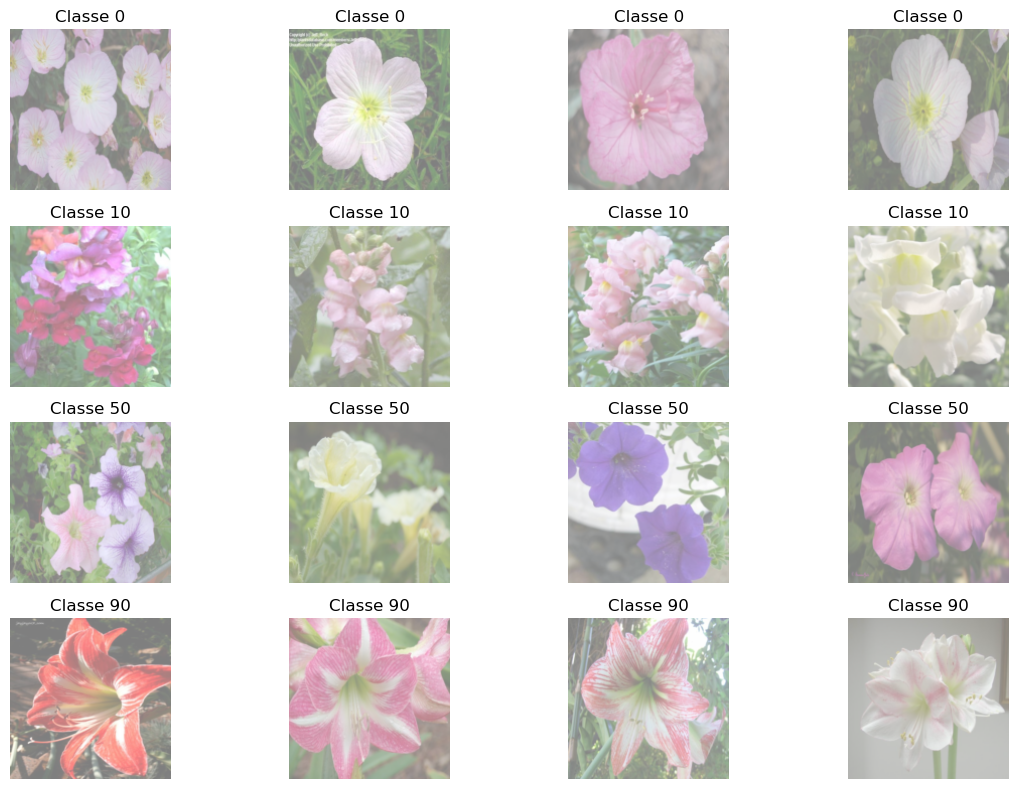

In [4]:
plt.figure(figsize=(12, 8))
classes_escolhidas = [0, 10, 50, 90]

for i, cls in enumerate(classes_escolhidas):
    imgs = [dataset[j][0] for j in range(len(dataset)) if dataset._labels[j] == cls][:4]
    for k in range(4):
        plt.subplot(len(classes_escolhidas), 4, i * 4 + k + 1)
        img = imgs[k]
        img = (img * 0.5 + 0.5).clamp(0, 1)  # unnormalize
        plt.imshow(img.permute(1, 2, 0))
        plt.title(f"Classe {cls}")
        plt.axis('off')

plt.tight_layout()
plt.show()